# P5-3. 최종 미니프로젝트 — 머신러닝 모델링 — 코드 구현 가이드

**주제: 고객 이탈(Churn) 예측 — 머신러닝 기준 모델 만들기**

## 수업 목적
P5 과정에서 학습한 머신러닝 내용을 바탕으로, 완성 코드를 그대로 따라 입력하지 않고
**데이터 준비 → 전처리 → 모델 학습 → 불균형 대응 → 평가 → 해석**의 전체 흐름을 직접 구현한다.

## 핵심 구현 흐름
`데이터 로드 → 데이터 확인 → One-Hot Encoding → X/y 분리 → Train/Test 분할 → 스케일링 → 모델 학습 → class_weight → 성능 비교 → 상세 평가`

## 구현 원칙
- `Churn`은 정답 데이터이므로 입력 특성에 포함하지 않는다.
- P5-4와 공정하게 비교할 수 있도록 `test_size=0.30`, `random_state=42`를 사용한다.
- 클래스 비율을 유지하도록 `stratify=y`를 적용한다.
- 스케일러는 Train 데이터에만 `fit`한다.
- Accuracy뿐 아니라 Precision, Recall, F1-score를 함께 비교한다.
- Test 데이터는 최종 평가용으로 사용하고 반복적인 모델 튜닝에 사용하지 않는다.

## 0. 라이브러리 준비
필요한 `pandas`, `numpy`, 시각화 도구와 scikit-learn의 전처리·분류·평가 모듈을 직접 불러온다.

**힌트:** `train_test_split`, `MinMaxScaler`, 4개의 분류 모델, 분류 평가지표가 필요하다.

In [80]:
# 필요한 라이브러리를 직접 작성한다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import tensorflow as tf
layers = tf.keras.layers

plt.rcParams["axes.unicode_minus"] = False
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
RANDOM_STATE = 42


## 1. 데이터 로드
`data_save.csv`를 DataFrame으로 읽고 데이터 크기와 앞부분을 확인한다.

**확인할 것:** 행/열 개수, `Churn` 컬럼 존재 여부

In [81]:
CONFIG = {
    "project_name": "customer",
    "task_type": "binary",
    "target": "churn",
    "primary_metric": "accuracy",
    "success_criterion": "accuracy가 가장 높은 모델을 선정하고 고객이탈여부를 예측한다.",
    "team": ["팀원A", "팀원B", "팀원C"],
    "test_size": 0.15,
    "val_size": 0.18,
}

# data_save.csv를 불러오고 데이터 크기와 앞 5개 행을 확인한다.
# 1. CSV 파일 불러오기
df = pd.read_csv("data_v2_save.csv")

# 2. 예측할 목표 변수 설정
CONFIG["target"] = "Churn"

# 3. X(입력 데이터)와 y(정답 데이터) 분리
X_df = df.drop(columns=[CONFIG["target"]])
y = df[CONFIG["target"]].values

print("데이터 형태:", df.shape)
df.head()


데이터 형태: (7027, 17)


,gender,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,No,No,34,No,DSL,Yes,No,No,No,No,One year,No,Mailed check,56.95,1889.50,0
1,Male,No,No,2,No,DSL,Yes,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
2,Male,No,No,45,No phone service,DSL,Yes,No,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
3,Female,No,No,2,No,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
4,Female,No,No,8,Yes,Fiber optic,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


## 2. 데이터 확인
`df.info()`로 자료형과 결측치를 확인하고 `Churn`의 개수 및 비율을 계산한다.

**생각할 것:** `Churn=1`이 적다면 Accuracy만으로 충분한가?

In [82]:
# 데이터 구조와 Churn 클래스 분포를 확인한다.
print("\n목표 변수 분포:")
u, cnt = np.unique(y, return_counts=True)
for k, v in zip(u, cnt):
    print(f"  {int(k)}: {v:5d}건 ({v/len(y):.1%})")

df.info()


목표 변수 분포:
  0:  5161건 (73.4%)
  1:  1866건 (26.6%)
<class 'pandas.DataFrame'>
RangeIndex: 7027 entries, 0 to 7026
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7027 non-null   str    
 1   Partner           7027 non-null   str    
 2   Dependents        7027 non-null   str    
 3   tenure            7027 non-null   int64  
 4   MultipleLines     7027 non-null   str    
 5   InternetService   7027 non-null   str    
 6   OnlineSecurity    7027 non-null   str    
 7   OnlineBackup      7027 non-null   str    
 8   TechSupport       7027 non-null   str    
 9   StreamingTV       7027 non-null   str    
 10  StreamingMovies   7027 non-null   str    
 11  Contract          7027 non-null   str    
 12  PaperlessBilling  7027 non-null   str    
 13  PaymentMethod     7027 non-null   str    
 14  MonthlyCharges    7027 non-null   float64
 15  TotalCharges      7027 non-null   float64
 16  Ch

## 3. 범주형 데이터 One-Hot Encoding
문자열형 컬럼을 찾아 `pd.get_dummies()`로 수치형으로 변환한다.

**힌트:** `select_dtypes()`로 범주형 컬럼을 찾을 수 있다.

In [83]:
# 범주형 컬럼을 찾고 One-Hot Encoding을 수행한다.

# 4. 문자형 범주형 데이터를 숫자로 변환
X_df = pd.get_dummies(X_df, drop_first=True)

print("전처리 후 X 형태:", X_df.shape)


전처리 후 X 형태: (7027, 26)


## 4. 입력(X)과 정답(y) 분리
`Churn`을 제외한 컬럼은 X, `Churn`은 y로 분리한다.

In [84]:
# X와 y를 분리하고 shape을 확인한다.

# 5. X를 float32 형태의 숫자 배열로 변환
X = X_df.values.astype("float32")
y = y.astype("float32")

# 특성 이름 저장
feature_names = X_df.columns.tolist()

## 5. Train/Test 분할
P5-4와 같은 Test 데이터를 만들 수 있도록 다음 조건을 적용한다.

- Test 비율: 30%
- `random_state=42`
- 클래스 비율 유지: `stratify=y`

In [85]:
# train_test_split()으로 Train/Test를 분리한다.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------------------------
# 1. Train / Test 분할
# ------------------------------------------------------------

# 분류 문제이므로 y의 비율을 유지하면서 나눈다.
stratify = y if CONFIG["task_type"] != "regression" else None

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=CONFIG["test_size"],
    random_state=RANDOM_STATE, stratify=stratify)
    
# ------------------------------------------------------------
# 2. Train / Validation 분할
# ------------------------------------------------------------
stratify_temp = y_temp if CONFIG["task_type"] != "regression" else None
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=CONFIG["val_size"],
    random_state=RANDOM_STATE, stratify=stratify_temp)

## 6. 스케일링
`MinMaxScaler`를 사용한다.

**중요**
1. Train 데이터로 `fit_transform()`
2. Test 데이터에는 같은 scaler로 `transform()`만 적용한다.

이 순서를 지켜야 데이터 누수를 방지할 수 있다.

In [86]:
# MinMaxScaler를 만들고 Train/Test 데이터를 변환한다.
# ------------------------------------------------------------
# 3. 표준화(Standard Scaling)
# ------------------------------------------------------------
scaler = MinMaxScaler()

# ⚠️scaler는 X_train에만 fit
X_train = scaler.fit_transform(X_train).astype("float32")   # 학습으로만 fit

# validation과 test는 transform만 한다.
X_val = scaler.transform(X_val).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

# ------------------------------------------------------------
# 4. 데이터 크기 확인
# ------------------------------------------------------------
print(f"train {X_train.shape}  ({len(X_train)/len(X):.0%})")
print(f"val   {X_val.shape}  ({len(X_val)/len(X):.0%})")
print(f"test  {X_test.shape}  ({len(X_test)/len(X):.0%})")

print("\n주의: test는 마지막 한 번만 사용한다. 튜닝에는 val만 쓴다.")

train (4897, 26)  (70%)
val   (1075, 26)  (15%)
test  (1055, 26)  (15%)

주의: test는 마지막 한 번만 사용한다. 튜닝에는 val만 쓴다.


## 7. 공통 평가 함수 구현
모든 모델을 동일한 기준으로 비교할 수 있도록 평가 함수를 만든다.

함수는 다음 값을 계산하도록 한다.
- Accuracy
- Precision
- Recall
- F1-score

**힌트:** 함수 입력은 `모델 이름, 학습된 모델, 평가 입력 데이터, 실제 정답` 정도로 구성할 수 있다.

In [87]:
# evaluate_model() 함수를 직접 구현한다.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score)


def evaluate(y_true, y_prob, threshold=0.5, task=None):
    """과제 유형에 맞는 지표를 dict로 반환한다."""
    task = task or CONFIG["task_type"]

    if task == "regression":
        pred = np.asarray(y_prob).ravel()
        return {
            "mae": round(mean_absolute_error(y_true, pred), 4),
            "rmse": round(float(np.sqrt(mean_squared_error(y_true, pred))), 4),
            "r2": round(r2_score(y_true, pred), 4),
        }

    prob = np.asarray(y_prob).ravel()
    pred = (prob > threshold).astype(int)
    return {
        "accuracy": round(accuracy_score(y_true, pred), 4),
        # 힌트: 위 accuracy와 같은 형태로 채운다 (zero_division=0 유지)
        "precision": round(precision_score(y_true, pred, zero_division=0), 4),   # ④
        "recall": round(recall_score(y_true, pred, zero_division=0), 4),  # ⑤
        "f1": round(f1_score(y_true, pred, zero_division=0), 4),  # ⑥
        "roc_auc": round(roc_auc_score(y_true, prob), 4),
        "pr_auc": round(average_precision_score(y_true, prob), 4),
    }


def show_confusion(y_true, y_prob, threshold=0.5, title=""):
    pred = (np.asarray(y_prob).ravel() > threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["예측 0", "예측 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 0", "실제 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(f"혼동행렬 {title}")
    plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()
    return cm


print("평가 함수 준비 완료. 주 지표:", CONFIG["primary_metric"])



평가 함수 준비 완료. 주 지표: accuracy


## 8. 머신러닝 기본 모델 학습
다음 4개 모델을 같은 Train/Test 데이터로 학습하고 평가한다.

- Logistic Regression
- KNN
- Decision Tree
- Random Forest

**권장 설정**
- Logistic Regression: `max_iter=1000`
- KNN: `n_neighbors=5`
- Decision Tree: `max_depth=10`
- Random Forest: `n_estimators=100`

각 모델의 결과와 예측값을 저장한다.

In [88]:
# 4개 모델을 정의하고 반복문으로 학습·평가한다.(모델 지정된 4가지로 수정함.)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time

baselines = {}
if CONFIG["task_type"] == "regression":
    from sklearn.linear_model import Ridge
    candidates = {"Ridge": Ridge()}
else:
    candidates = {
        "로지스틱 회귀": LogisticRegression(max_iter=2000),
        "Decision Tree": DecisionTreeClassifier(max_depth=10,
                                       random_state=RANDOM_STATE),
        "랜덤 포레스트": RandomForestClassifier(n_estimators=300,
                                          random_state=RANDOM_STATE, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }

rows = []
for name, clf in candidates.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    sec = time.time() - t0
    prob = (clf.predict(X_val) if CONFIG["task_type"] == "regression"
            else clf.predict_proba(X_val)[:, 1])
    sc = evaluate(y_val, prob)
    sc.update({"모델": name, "학습시간": round(sec, 2)})
    rows.append(sc)
    baselines[name] = (clf, prob)
    print(f"{name:14s} {CONFIG['primary_metric']}={sc[CONFIG['primary_metric']]}")

df_base = pd.DataFrame(rows).set_index("모델")
df_base


로지스틱 회귀        accuracy=0.7935
Decision Tree  accuracy=0.7572
랜덤 포레스트        accuracy=0.7879
KNN            accuracy=0.7377


,accuracy,precision,recall,f1,roc_auc,pr_auc,학습시간
모델,,,,,,,
로지스틱 회귀,0.7935,0.6376,0.5123,0.5681,0.8272,0.6026,0.03
Decision Tree,0.7572,0.5411,0.5544,0.5477,0.7254,0.4427,0.02
랜덤 포레스트,0.7879,0.6234,0.5053,0.5581,0.8134,0.5961,1.02
KNN,0.7377,0.5055,0.4877,0.4964,0.7525,0.4702,0.00


## 9. 클래스 불균형 대응 — class_weight
다음 두 모델에 `class_weight="balanced`를 적용한 모델을 추가한다.

- Logistic Regression
- Random Forest

기본 모델과 Recall, Precision, F1의 변화가 어떻게 나타나는지 비교한다.

In [89]:
# class_weight='balanced' 모델을 추가 학습하고 결과를 저장한다.
baselines = {}
if CONFIG["task_type"] == "regression":
    from sklearn.linear_model import Ridge
    candidates = {"Ridge": Ridge()}
else:
    candidates = {
        "로지스틱 회귀": LogisticRegression(max_iter=2000,
                                       class_weight="balanced"),
        "Decision Tree": DecisionTreeClassifier(max_depth=10,
                                       random_state=RANDOM_STATE),
        "랜덤 포레스트": RandomForestClassifier(n_estimators=300,
                                          class_weight="balanced",
                                          random_state=RANDOM_STATE, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }

rows = []
for name, clf in candidates.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    sec = time.time() - t0
    prob = (clf.predict(X_val) if CONFIG["task_type"] == "regression"
            else clf.predict_proba(X_val)[:, 1])
    sc = evaluate(y_val, prob)
    sc.update({"모델": name, "학습시간": round(sec, 2)})
    rows.append(sc)
    baselines[name] = (clf, prob)
    print(f"{name:14s} {CONFIG['primary_metric']}={sc[CONFIG['primary_metric']]}")

print('로지스틱 회귀와 랜덤포레스트의 recall, f1score가 상승하였다.')
df_base = pd.DataFrame(rows).set_index("모델")
df_base


로지스틱 회귀        accuracy=0.7293
Decision Tree  accuracy=0.7572
랜덤 포레스트        accuracy=0.7656
KNN            accuracy=0.7377
로지스틱 회귀와 랜덤포레스트의 recall, f1score가 상승하였다.


,accuracy,precision,recall,f1,roc_auc,pr_auc,학습시간
모델,,,,,,,
로지스틱 회귀,0.7293,0.4936,0.8070,0.6125,0.8271,0.6020,0.03
Decision Tree,0.7572,0.5411,0.5544,0.5477,0.7254,0.4427,0.02
랜덤 포레스트,0.7656,0.5484,0.6561,0.5974,0.8156,0.5861,0.97
KNN,0.7377,0.5055,0.4877,0.4964,0.7525,0.4702,0.00


## 10. 최종 성능 비교
모든 결과를 하나의 DataFrame으로 정리한다.

**권장 정렬 기준**
1. Recall 내림차순
2. F1 내림차순

Recall과 F1을 막대그래프로 비교해도 좋다.

In [90]:
# 결과 DataFrame을 만들고 성능을 비교한다.

df_base.sort_values(by='recall', ascending=False)
# df_base.sort_values(by='f1', ascending=False)(순위가 같음)

,accuracy,precision,recall,f1,roc_auc,pr_auc,학습시간
모델,,,,,,,
로지스틱 회귀,0.7293,0.4936,0.8070,0.6125,0.8271,0.6020,0.03
랜덤 포레스트,0.7656,0.5484,0.6561,0.5974,0.8156,0.5861,0.97
Decision Tree,0.7572,0.5411,0.5544,0.5477,0.7254,0.4427,0.02
KNN,0.7377,0.5055,0.4877,0.4964,0.7525,0.4702,0.00


## 11. 선택 모델 상세 평가
프로젝트 목적을 **'이탈 고객을 놓치지 않는 것'**으로 가정한다.

Recall이 높은 대표 모델 하나를 선택하여 다음을 출력한다.
- `classification_report`
- Confusion Matrix

**해석 포인트:** False Negative가 어떤 의미인지 설명한다.

선택된 모델: 로지스틱 회귀

              precision    recall  f1-score   support

         0.0       0.89      0.72      0.80       775
         1.0       0.50      0.76      0.60       280

    accuracy                           0.73      1055
   macro avg       0.70      0.74      0.70      1055
weighted avg       0.79      0.73      0.75      1055



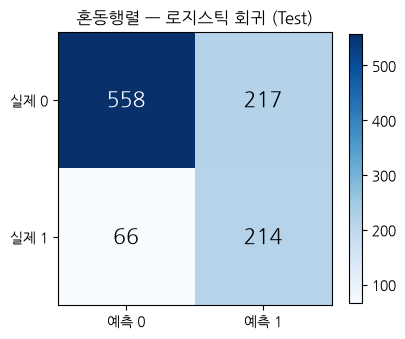

In [91]:
# 대표 모델을 선택하고 상세 평가를 수행한다.

# 대표 모델을 선택하고 상세 평가를 수행한다.
from sklearn.metrics import classification_report

# 1. df_base에서 recall이 가장 높은 모델 이름 선택
best_model_name = df_base["recall"].idxmax()
best_model, _ = baselines[best_model_name]

print(f"선택된 모델: {best_model_name}\n")

# 2. Test 데이터로 최종 예측 (여기서 처음 X_test 사용)
prob_test = (best_model.predict(X_test) if CONFIG["task_type"] == "regression"
             else best_model.predict_proba(X_test)[:, 1])
pred_test = (prob_test > 0.5).astype(int)

# 3. classification_report
print(classification_report(y_test, pred_test))

# 4. Confusion Matrix (Cell 16에서 만든 show_confusion 재사용)
cm = show_confusion(y_test, prob_test, title=f"— {best_model_name} (Test)")

## 12. 결과 해석
다음 질문에 답한다.

1. Accuracy가 가장 높은 모델과 Recall이 가장 높은 모델이 같은가? : 랜덤포레스트 vs 로지스틱 회귀
2. `class_weight='balanced'` 적용 전후 Recall과 Precision은 어떻게 달라졌는가? : Recall=눈에 띄게 증가. 반면, precision은 하락.
3. 이탈 고객을 놓치는 비용이 크다면 어떤 모델을 선택하겠는가? : 로지스틱 회귀 모델
4. P5-4의 DNN과 비교할 머신러닝 대표 모델은 무엇인가? : 로지스틱 회귀 모델

## 최종 점검표
| 확인 항목 | 핵심 기준 |
|---|---|
| 전처리 | 범주형 컬럼을 One-Hot Encoding 했는가 |
| 데이터 분리 | P5-4와 동일한 Test 분할 조건을 사용했는가 |
| Stratify | 클래스 비율을 유지했는가 |
| 스케일링 | Train에만 fit했는가 |
| 모델 | 4개 기본 모델을 비교했는가 |
| 불균형 대응 | class_weight 적용 모델을 추가했는가 |
| 평가 | Accuracy, Precision, Recall, F1을 사용했는가 |
| 상세 분석 | classification report와 confusion matrix를 확인했는가 |
| 해석 | 성능 숫자뿐 아니라 프로젝트 목적에 맞게 모델을 선택했는가 |